Dataset loaded successfully!
Dataset shape: (50, 7)

First 5 rows:



,Student_ID,Study_Hours,Attendance,Previous_Marks,Assignments_Score,Sleep_Hours,Result
0,S001,2.0,65,45,50,6,Fail
1,S002,5.0,82,68,75,7,Pass
2,S003,1.5,55,38,42,5,Fail
3,S004,6.0,90,78,85,8,Pass
4,S005,4.0,75,60,65,7,Pass



DATASET INFORMATION

Column names:
['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments_Score', 'Sleep_Hours', 'Result']

Data types:
Student_ID            object
Study_Hours          float64
Attendance             int64
Previous_Marks         int64
Assignments_Score      int64
Sleep_Hours            int64
Result                object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         50 non-null     object 
 1   Study_Hours        50 non-null     float64
 2   Attendance         50 non-null     int64  
 3   Previous_Marks     50 non-null     int64  
 4   Assignments_Score  50 non-null     int64  
 5   Sleep_Hours        50 non-null     int64  
 6   Result             50 non-null     object 
dtypes: float64(1), int64(4), object(2)
memory usage: 2.9+ KB

MISSING

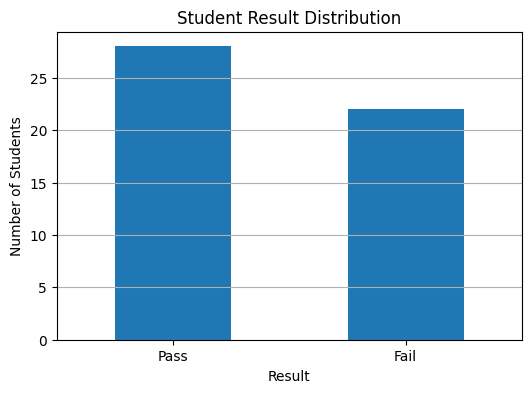


FEATURES AND TARGET

Features used for prediction:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignments_Score', 'Sleep_Hours']

Target:
Result

TRAIN-TEST SPLIT
Training samples: 40
Testing samples: 10

DECISION TREE RESULTS
Accuracy: 80.0 %

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.50      0.67         4
        Pass       0.75      1.00      0.86         6

    accuracy                           0.80        10
   macro avg       0.88      0.75      0.76        10
weighted avg       0.85      0.80      0.78        10


RANDOM FOREST RESULTS
Accuracy: 90.0 %

Classification Report:
              precision    recall  f1-score   support

        Fail       1.00      0.75      0.86         4
        Pass       0.86      1.00      0.92         6

    accuracy                           0.90        10
   macro avg       0.93      0.88      0.89        10
weighted avg       0.91      0.90      0.90        10


MODEL 

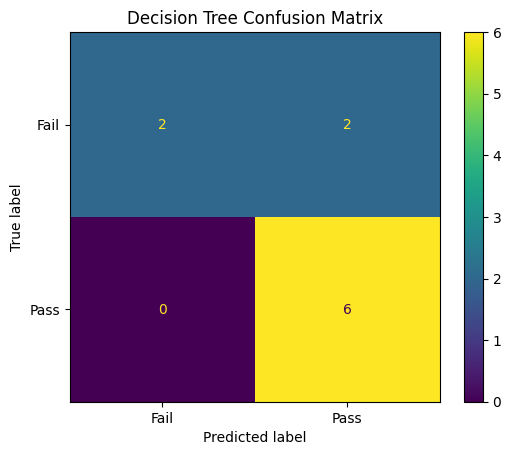


RANDOM FOREST CONFUSION MATRIX
[[3 1]
 [0 6]]


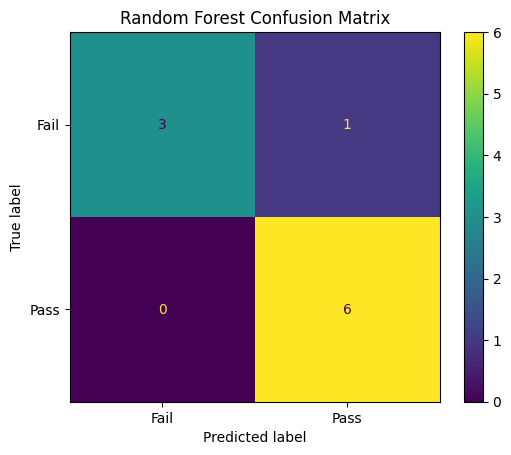


ROC CURVE AND AUC


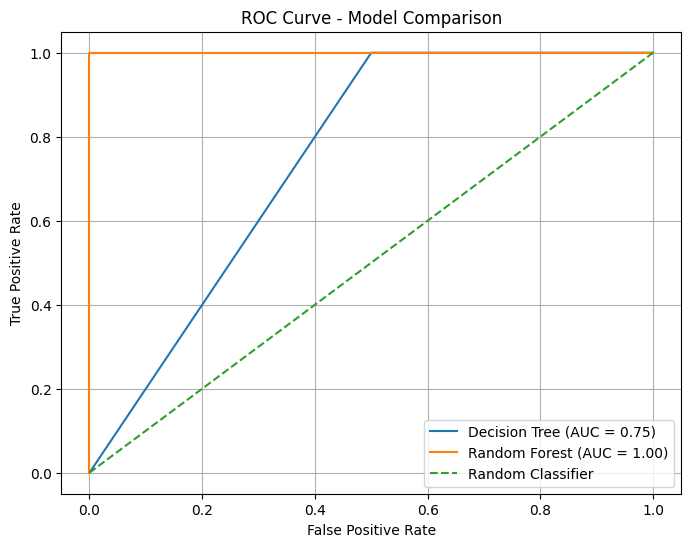

Decision Tree AUC: 0.75
Random Forest AUC: 1.0

FEATURE IMPORTANCE
             Feature  Importance
0        Study_Hours    0.319098
2     Previous_Marks    0.301366
3  Assignments_Score    0.254333
1         Attendance    0.115382
4        Sleep_Hours    0.009822


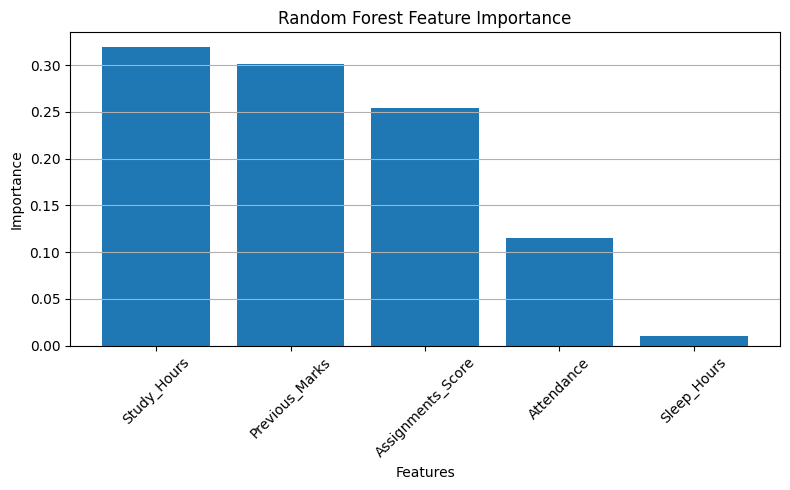


NEW STUDENT PREDICTION

New Student Details:


,Study_Hours,Attendance,Previous_Marks,Assignments_Score,Sleep_Hours
0,6.0,90,78,85,8



Predicted Result: Pass

FINAL SUMMARY
Dataset size: (50, 7)
Decision Tree Accuracy: 80.0 %
Random Forest Accuracy: 90.0 %
Decision Tree AUC: 0.75
Random Forest AUC: 1.0
Best Model: Random Forest
Best Accuracy: 90.0 %

CONCLUSION

The machine learning models were successfully trained
using student performance data.

The models predict whether a student is likely to Pass
or Fail based on Study Hours, Attendance, Previous Marks,
Assignments Score and Sleep Hours.

Decision Tree and Random Forest classification algorithms
were applied and evaluated using accuracy, classification
report and confusion matrix.

ROC Curve and AUC were also used to evaluate the
classification performance of the models.

The best performing model was selected based on accuracy.

The Random Forest model was used to predict the result
of a new student.

Thus, this project demonstrates the use of supervised
machine learning for student performance prediction.



In [ ]:
# ============================================================
# PREDICTIVE MODELING USING MACHINE LEARNING
# STUDENT PERFORMANCE PREDICTION
# ============================================================

# ============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)


# ============================================================
# 2. LOAD ALREADY UPLOADED DATASET
# ============================================================

# Use the exact CSV file name that you already uploaded
df = pd.read_csv('/content/Student_Performance.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)


# ============================================================
# 3. DISPLAY FIRST 5 ROWS
# ============================================================

print("\nFirst 5 rows:\n")
display(df.head())


# ============================================================
# 4. DATASET INFORMATION
# ============================================================

print("\n========================================")
print("DATASET INFORMATION")
print("========================================")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n========================================")
print("MISSING VALUES")
print("========================================")

print(df.isnull().sum())


# ============================================================
# 6. CHECK DUPLICATE ROWS
# ============================================================

print("\n========================================")
print("DUPLICATE ROWS")
print("========================================")

print("Duplicate rows:", df.duplicated().sum())


# ============================================================
# 7. DATA CLEANING / PREPROCESSING
# ============================================================

# Remove duplicate rows
df = df.drop_duplicates()

# Numerical columns
numeric_columns = [
    'Study_Hours',
    'Attendance',
    'Previous_Marks',
    'Assignments_Score',
    'Sleep_Hours'
]

# Fill missing numerical values using median
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

# Fill missing target values using mode
df['Result'] = df['Result'].fillna(df['Result'].mode()[0])

print("\nData cleaning completed!")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())


# ============================================================
# 8. RESULT DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

df['Result'].value_counts().plot(kind='bar')

plt.title("Student Result Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.grid(axis='y')

plt.show()


# ============================================================
# 9. DEFINE FEATURES AND TARGET
# ============================================================

features = [
    'Study_Hours',
    'Attendance',
    'Previous_Marks',
    'Assignments_Score',
    'Sleep_Hours'
]

X = df[features]

y = df['Result']

print("\n========================================")
print("FEATURES AND TARGET")
print("========================================")

print("\nFeatures used for prediction:")
print(features)

print("\nTarget:")
print("Result")


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========================================")
print("TRAIN-TEST SPLIT")
print("========================================")

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 11. DECISION TREE
# ============================================================

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test,
    dt_predictions
)

print("\n========================================")
print("DECISION TREE RESULTS")
print("========================================")

print(
    "Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        dt_predictions
    )
)


# ============================================================
# 12. RANDOM FOREST
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print("\n========================================")
print("RANDOM FOREST RESULTS")
print("========================================")

print(
    "Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions
    )
)


# ============================================================
# 13. MODEL COMPARISON
# ============================================================

print("\n========================================")
print("MODEL COMPARISON")
print("========================================")

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

if rf_accuracy >= dt_accuracy:
    best_model = rf_model
    best_model_name = "Random Forest"
    best_accuracy = rf_accuracy
else:
    best_model = dt_model
    best_model_name = "Decision Tree"
    best_accuracy = dt_accuracy

print("\nBest Model:", best_model_name)

print(
    "Best Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)


# ============================================================
# 14. DECISION TREE CONFUSION MATRIX
# ============================================================

print("\n========================================")
print("DECISION TREE CONFUSION MATRIX")
print("========================================")

dt_cm = confusion_matrix(
    y_test,
    dt_predictions,
    labels=['Fail', 'Pass']
)

print(dt_cm)

dt_display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=['Fail', 'Pass']
)

dt_display.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()


# ============================================================
# 15. RANDOM FOREST CONFUSION MATRIX
# ============================================================

print("\n========================================")
print("RANDOM FOREST CONFUSION MATRIX")
print("========================================")

rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=['Fail', 'Pass']
)

print(rf_cm)

rf_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=['Fail', 'Pass']
)

rf_display.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()


# ============================================================
# 16. ROC CURVE AND AUC
# ============================================================

print("\n========================================")
print("ROC CURVE AND AUC")
print("========================================")

# Convert Pass/Fail into binary values
# Fail = 0
# Pass = 1

y_test_binary = (y_test == 'Pass').astype(int)


# ------------------------------------------------------------
# Decision Tree probabilities
# ------------------------------------------------------------

dt_probabilities = dt_model.predict_proba(X_test)

dt_pass_index = list(
    dt_model.classes_
).index('Pass')

dt_pass_probability = dt_probabilities[
    :, dt_pass_index
]


# ------------------------------------------------------------
# Random Forest probabilities
# ------------------------------------------------------------

rf_probabilities = rf_model.predict_proba(X_test)

rf_pass_index = list(
    rf_model.classes_
).index('Pass')

rf_pass_probability = rf_probabilities[
    :, rf_pass_index
]


# ------------------------------------------------------------
# Decision Tree ROC
# ------------------------------------------------------------

dt_fpr, dt_tpr, _ = roc_curve(
    y_test_binary,
    dt_pass_probability
)

dt_auc = auc(
    dt_fpr,
    dt_tpr
)


# ------------------------------------------------------------
# Random Forest ROC
# ------------------------------------------------------------

rf_fpr, rf_tpr, _ = roc_curve(
    y_test_binary,
    rf_pass_probability
)

rf_auc = auc(
    rf_fpr,
    rf_tpr
)


# ============================================================
# 17. ROC CURVE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f"Decision Tree (AUC = {dt_auc:.2f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.2f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Model Comparison")

plt.legend()

plt.grid()

plt.show()


# ============================================================
# 18. AUC VALUES
# ============================================================

print("Decision Tree AUC:", round(dt_auc, 2))

print("Random Forest AUC:", round(rf_auc, 2))


# ============================================================
# 19. FEATURE IMPORTANCE
# ============================================================

print("\n========================================")
print("FEATURE IMPORTANCE")
print("========================================")

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)


# ============================================================
# 20. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.tight_layout()

plt.show()


# ============================================================
# 21. NEW STUDENT PREDICTION
# ============================================================

print("\n========================================")
print("NEW STUDENT PREDICTION")
print("========================================")

# Example new student

new_student = pd.DataFrame({
    'Study_Hours': [6.0],
    'Attendance': [90],
    'Previous_Marks': [78],
    'Assignments_Score': [85],
    'Sleep_Hours': [8]
})

print("\nNew Student Details:")
display(new_student)


# Predict using Random Forest
new_prediction = rf_model.predict(
    new_student
)

print(
    "\nPredicted Result:",
    new_prediction[0]
)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n========================================")
print("FINAL SUMMARY")
print("========================================")

print("Dataset size:", df.shape)

print(
    "Decision Tree Accuracy:",
    round(dt_accuracy * 100, 2),
    "%"
)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

print(
    "Decision Tree AUC:",
    round(dt_auc, 2)
)

print(
    "Random Forest AUC:",
    round(rf_auc, 2)
)

print("Best Model:", best_model_name)

print(
    "Best Accuracy:",
    round(best_accuracy * 100, 2),
    "%"
)


# ============================================================
# 23. CONCLUSION
# ============================================================

print("\n========================================")
print("CONCLUSION")
print("========================================")

print("""
The machine learning models were successfully trained
using student performance data.

The models predict whether a student is likely to Pass
or Fail based on Study Hours, Attendance, Previous Marks,
Assignments Score and Sleep Hours.

Decision Tree and Random Forest classification algorithms
were applied and evaluated using accuracy, classification
report and confusion matrix.

ROC Curve and AUC were also used to evaluate the
classification performance of the models.

The best performing model was selected based on accuracy.

The Random Forest model was used to predict the result
of a new student.

Thus, this project demonstrates the use of supervised
machine learning for student performance prediction.
""")